In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplsbdb import SBDB
from pathlib import Path
import glob
import io

import rebound as rb
import celmech as cm
import assist
import xgboost as xgb

from linear_theory import linear_theory_prediction, make_simpler_secular_theory
from utils import ecliptic_to_icrf, icrf_to_ecliptic, ecliptic_xyz_to_elements, UNIT_CONVER, epoch as nesvorny_epoch

from tqdm import tqdm

Searching NASA Horizons for 'sun'... 
Found: Sun (10) 


# Step 1: integrating backwards

If the epoch the orbit was measured at is not exactly equal to the epoch used by Nesvorny'25 (JD2460200.5), then a backward integration needs to be performed with the ephemeris integrator ASSIST.

There are two main ways of adding new objects, either using an assigned designator and querying NASA Horizons (1.1), or by manually inputting orbital elements (1.2). NASA Horizons and rebound both use the J2000 eclipltic frame, but ASSIST uses ICRF. In this section, we add objects in the J2000 ecliptic frame, and convert them to ICRF in section 2.

## 1.1 Search with Designation

In [2]:
# Get two example asteroids to test from horizons
des = ['K09WK5U', 'K22SH4P'] # first one is in the velleda family, second is not in any families
epoch = 2460400.5

In [3]:
# Query horizons to get the position of each asteroid
df1 = []
for d in des:
	sim = rb.Simulation()
	sim.add(d, date = "JD%f"%epoch)
	p = sim.particles[-1]
	df1.append({
		"Des'n": d,
		"epoch": epoch,
		"x": p.x, 
		"y": p.y, 
		"z": p.z, 
		"vx": p.vx, 
		"vy": p.vy, 
		"vz": p.vz
	})

Searching NASA Horizons for 'K09WK5U'... 
Found: 854145 (2009 WU205) 
Searching NASA Horizons for 'K22SH4P'... 


/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: (2022 SP174) 


## 1.2 Direct input of state vector

In [4]:
# Add our custom asteroid
df1.append({
    "Des'n": "custom-velleda", # an asteroid that should be in the valleda family
	"epoch": epoch,
	"x": -1.641552, # AU
	"y": -1.619824, 
	"z": 0.080764, 
	"vx": 0.485864, # AU/(yr/2pi)
	"vy": -0.47166, 
	"vz": 0.019807
})

In [5]:
# the list of asteroids we want to identify the families of (in J2000 ecliptic)
df_e = pd.DataFrame(df1)
df_e

,Des'n,epoch,x,y,z,vx,vy,vz
0,K09WK5U,2460400.5,1.912438,-1.547085,-0.048718,0.360054,0.522457,0.025167
1,K22SH4P,2460400.5,-2.948099,1.216023,0.188739,-0.239522,-0.418972,0.049165
2,custom-velleda,2460400.5,-1.641552,-1.619824,0.080764,0.485864,-0.471660,0.019807


## 1.3 Use Assist to integrate asteroids back to JD2460200.5

In [6]:
# Lists to store calculated osculating orbital elements
a_list = []
e_list = []
inc_list = []
Omega_list = []
omega_list = []

# Load epehemeris files for ASSIST
ephem = assist.Ephem("data/assist/linux_m13000p17000.441", "data/assist/sb441-n16.bsp")

# Calculate osculating elements for all asteroids at the nesvorny epoch
for i in range(len(df_e)):
	ast = df_e.iloc[i]

	### Convert orbital elements in xyz, vxyz ###
	sim = rb.Simulation()
	sim.add("Sun", date = "JD%f"%ast["epoch"])
	sim.add(x = ast["x"].item(),
			y = ast["y"].item(),
			z = ast["z"].item(),
			vx = ast["vx"].item()/UNIT_CONVER,
			vy = ast["vy"].item()/UNIT_CONVER,
			vz = ast["vz"].item()/UNIT_CONVER)
	p = sim.particles[1]
	# Rotate to icrf
	p = ecliptic_to_icrf(p)
	
	### Use ASSIST to integrate backwards to Nesvorny epoch ###
	# Setup sim
	sim_a = rb.Simulation()
	ex = assist.Extras(sim_a, ephem)
	ex.gr_eih_sources = 11
	sim_a.ri_ias15.adaptive_mode = 2
	sim_a.exit_max_distance = 50.0
	sim_a.t = epoch - ephem.jd_ref

	# Add particle
	sim_a.add(p, plane="frame")

	# Integrate
	ex.integrate_or_interpolate(nesvorny_epoch - ephem.jd_ref)
	
	# Retrieve the orbital elements
	p = sim_a.particles[-1]
	p = icrf_to_ecliptic(p)
	p.vxyz = np.array(p.vxyz) * UNIT_CONVER
	orbit = ecliptic_xyz_to_elements(p)
	
	a_list.append(orbit.a)
	e_list.append(orbit.e)
	inc_list.append(orbit.inc)
	Omega_list.append(orbit.Omega)
	omega_list.append(orbit.omega)

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Sun'... 


/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/rebound/simulation.py:927: RuntimeWarning: Particle added is from a simulation that uses different units.
  warnings.warn("Particle added is from a simulation that uses different units.", RuntimeWarning)


Found: Sun (10) 


In [7]:
# for the test asteroids we provde, these should all be roughly 2.4-2.5
# if they are not then try restarting the notebook and re-running the cell above and making sure you have the correct version of assist
a_list

[2.4495308875925903, 2.5507862448026892, 2.4304780756332236]

Extract only the orbital elments we need into a separate dataframe that is used with the ML model

In [8]:
merged_df = pd.DataFrame({"Des'n": df_e["Des'n"],
    					  'a': np.abs(a_list), 
						  'e': e_list, 
						  'Incl.': inc_list, 
						  'Node': Omega_list, 
						  'Peri.': omega_list})

merged_df

,Des'n,a,e,Incl.,Node,Peri.
0,K09WK5U,2.449531,0.075273,0.043104,-0.198593,1.245513
1,K22SH4P,2.550786,0.280964,0.111640,2.191856,4.057564
2,custom-velleda,2.430478,0.057222,0.046103,3.058625,1.229569


In [9]:
# Load nesvorny dataset
df = pd.read_csv("data/merged_elements.csv")
# Verify that we correctly integrated backwards
# a and e should match the first row in the above table exactly, Incl., Node, and Peri. need to be converted from deg to rad to match
df[df["Des'n"] == "K09WK5U"][['a', 'e', 'Incl.', 'Node', 'Peri.']]

/tmp/ipykernel_146892/555981324.py:2: DtypeWarning: Columns (0: Des'n) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_elements.csv")


,a,e,Incl.,Node,Peri.
727337,2.449531,0.075273,2.46966,348.62156,71.36248


# Step 2. Linear prediction

TODO: ADD EXPLANATION OF HOW LINEAR THEORY WORKS, what folder, etc.

In [10]:
# Lists to store calculated linear estimate of proper orbital elements
u0_list = []
v0_list = []
g0_list = []
s0_list = []

# Load files for linear theory
simpler_secular_theory = make_simpler_secular_theory()

# Calculate linear estimate for each candidate asteroid
for i,ast in merged_df.iterrows():
	u0, v0, g0, s0 = linear_theory_prediction(ast["e"], ast['Incl.'], ast['Peri.'], ast['Node'], ast['a'], simpler_secular_theory)
	u0_list.append(u0)
	v0_list.append(v0)
	g0_list.append(g0)
	s0_list.append(s0)

merged_df['prope_h']    = [np.abs(complex(x)) for x in u0_list]
merged_df['propsini_h'] = [np.sin(np.abs(complex(x))) for x in v0_list]
merged_df['g0'] = g0_list
merged_df['s0'] = s0_list

# Step 3. Predict the Proper Elements

In [11]:
# Calculate feature vector for each asteroid
merged_df["prope_h"] = np.abs(merged_df["prope_h"])
merged_df["propsini_h"] = np.abs(merged_df["propsini_h"])
merged_df['prope_h'] = pd.to_numeric(merged_df['prope_h'], errors='coerce')
merged_df['propsini_h'] = pd.to_numeric(merged_df['propsini_h'], errors='coerce')
merged_df['Node'] = pd.to_numeric(merged_df['Node'], errors='coerce')
merged_df['Peri.'] = pd.to_numeric(merged_df['Peri.'], errors='coerce')
merged_df['ecospo'] = merged_df['prope_h']*np.cos((merged_df['Node']+merged_df['Peri.']))
merged_df['esinpo'] = merged_df['prope_h']*np.sin((merged_df['Node']+merged_df['Peri.']))
merged_df['sinicosO'] = merged_df['propsini_h']*np.cos(merged_df['Node'])
merged_df['sinisinO'] = merged_df['propsini_h']*np.sin(merged_df['Node'])

In [12]:
# Load trained models (can be downloaded here: https://doi.org/10.5281/zenodo.20693708)
final_model_e = xgb.XGBRegressor()
final_model_e.load_model("data/models/best_model_e_final.xgb")
final_model_inc = xgb.XGBRegressor()
final_model_inc.load_model("data/models/best_model_inc_final.xgb")

/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/xgboost/sklearn.py:1132: UserWarning: [06:45:02] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1500: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


In [13]:
# Use models to estimate proper elements, which will be stored in "pred_e" and "pred_sini"
features_e = ['sinicosO', 'sinisinO', 'ecospo', 'esinpo', 'a', 'g0', 'prope_h']
features_inc = ['sinicosO', 'sinisinO', 'ecospo', 'esinpo', 'a', 's0', 'propsini_h']

dele = final_model_e.predict(merged_df[features_e])
delsini = final_model_inc.predict(merged_df[features_inc])

merged_df["pred_e"] = merged_df["e"] + dele
merged_df["pred_sini"] = np.sin(merged_df["Incl."]) + delsini

# Step 4. Family Classification

#### $d$ metric: Nesvorny et. al '24 eqn 1
$$d = {3 \times 10^4\, {\rm m/s} \over \sqrt{a_{\rm p}}} \sqrt{ {5 \over 4} 
\left({\delta a_{\rm p}/a_{\rm p}}\right)^2 + 2 (\delta e_{\rm p})^2 + 2 (\delta \sin i_{\rm p})^2}$$
$d$ is a velocity metric threshold used to cutoff which asteroids are part of a family

In [14]:
def calculate_d(a_p, delta_a_p, delta_e_p, delta_sin_i_p):
	numerator = 3e4  # 3 × 10^4 m/s
	denominator = np.sqrt(a_p)
	term1 = (delta_a_p / a_p) ** 2
	term2 = 2 * (delta_e_p ** 2)
	term3 = 2 * (delta_sin_i_p ** 2)
	inside_sqrt = (5 / 4) * term1 + term2 + term3
	d = (numerator / denominator) * np.sqrt(inside_sqrt)
	return d

#### Find the $d$ threshold value that Nesvorny et al. '24 used for each asteroid family

In [15]:
def extract_table_from_txt(path):
	with open(path, "r") as f:
		lines = f.readlines()

	start = None
	for i, line in enumerate(lines):
		if line.strip().startswith("Number"):
			start = i
			break

	end = None
	for i, line in enumerate(lines[start:], start=start):
		if line.strip().startswith("Note."):
			end = i
			break

	table_lines = lines[start:end]

	df = pd.read_csv(io.StringIO("".join(table_lines)), sep="\t+", engine="python")
	df['Name'] = df["Name"].str.replace("-","_")
	return df

# Collect all family txt files in data folder
all_files = glob.glob("data/family_d_vals/*.txt")

# Extract and merge
df_list = [extract_table_from_txt(file) for file in all_files]
df_d = pd.concat(df_list, ignore_index=True)

#### Find the top 5 families that the candidate asteroid is most likely to be a part of

For each candidate asteroid, we find the distance from that asteroid to the *leading* asteroid in each family. We keep the 5 families that the candidate is closest to in $d$ as potential host families to search more thoroughly in the next step.

In [16]:
# Load all asteroid families
dataset_path = Path('data/family_tables')
filenames = list(dataset_path.glob('*.csv'))

# array to store potential families for each candidate
results = []

# loop through candidates
for i in range(len(merged_df)):
	# get candidate proper elements
	ast = merged_df.iloc[i]
	ast_a = ast["a"]
	ast_prope = ast["pred_e"]
	ast_propsini = ast["pred_sini"]

	# find the distance between the candidate and the leading asteroid of each family
	pairs = []  # (family_number, d)
	print(str(ast["Des'n"])+":")
	for filename in tqdm(filenames):
		# Load the family
		df_family = pd.read_csv(filename, header=None, names=['propa', 'prope', 'propsini', 'g', 's', 'H',
				'NumOpps', 'PackedName', 'UnpackedName'])
		family_number = str(filename).split("/")[-1].split(".")[0].split("_")[1]

		# get the designator of the leading asteroid
		desn = df_family.iloc[0, 7]
		if str(desn).isdigit():
			desn = int(desn)

		# get the leading nbody proper elements of the leading asteroid
		ast_f = df[df["Des'n"] == desn]

		if ast_f.empty:
			continue

		# find the distance to the family and save in `pairs`
		da = ast_f['a'].values[0] - ast_a
		de = ast_f['prope'].values[0] - ast_prope
		dsini = ast_f['propsini'].values[0] - ast_propsini

		d = calculate_d(ast_a, da, de, dsini)

		pairs.append((family_number, d))

	pairs_sorted = sorted(pairs, key=lambda x: x[1])

	# take top 5 families that the candidate is closet to
	top5 = pairs_sorted[:5]

	results.append({
		"asteroid_index": i,
		"top5_families": [f for f, d in top5],
	})

results_df = pd.DataFrame(results)

K09WK5U:


100%|██████████| 153/153 [00:09<00:00, 15.70it/s]


K22SH4P:


100%|██████████| 153/153 [00:09<00:00, 15.62it/s]


custom-velleda:


100%|██████████| 153/153 [00:09<00:00, 15.66it/s]


Now we know which families each candidate is likely to be a part of.

For each potential family, we find the distance from the candidate asteroid to every asteroid in the family. If the distance $d$ between the candidate and *any* family member is less than the threshold specified by Nesvorny et. al. '24, then we consider the asteroid to be in the family.

In [17]:
column_names = ['propa', 'prope', 'propsini', 'g', 's', 'H', 'NumOpps', 'PackedName', 'UnpackedName']

family_file_map = {
	f.stem.split("_")[1]: f
	for f in filenames
}

d_cutoff_map = (
	df_d.assign(Number=df_d["Number"].astype(str))
		.set_index("Number")["HCM Cut"]
		.to_dict()
)

df_lookup = df[["Des'n", "a", "prope", "propsini"]].copy()

family_data = {}

for family_number, file_path in family_file_map.items():
	if family_number not in d_cutoff_map:
		continue

	df_family = pd.read_csv(
		file_path,
		header=None,
		names=column_names
	)
	
	df_family = df_family[["PackedName"]]

	fam = df_family.merge(
		df_lookup,
		left_on="PackedName",
		right_on="Des'n",
		how="inner"
	)

	if fam.empty:
		continue

	family_data[family_number] = {
		"a": fam["a"].to_numpy(float),
		"e": fam["prope"].to_numpy(float),
		"sini": fam["propsini"].to_numpy(float),
		"d_cutoff": d_cutoff_map[family_number],
	}
matched_families_all = []

for ast_a, ast_prope, ast_propsini, top5_families in zip(
	merged_df["a"].to_numpy(float),
	merged_df["pred_e"].to_numpy(float),
	merged_df["pred_sini"].to_numpy(float),
	results_df["top5_families"]
):
	matched_families = []

	for family_number in top5_families:
		family_number = str(family_number)

		if family_number not in family_data:
			continue

		fam = family_data[family_number]

		da = fam["a"] - ast_a
		de = fam["e"] - ast_prope
		dsini = fam["sini"] - ast_propsini

		d = calculate_d(ast_a, da, de, dsini)

		if np.any(d <= fam["d_cutoff"]):
			matched_families.append(family_number)

	matched_families_all.append(matched_families)

results_df["matched_families"] = matched_families_all

In [18]:
results_df

,asteroid_index,top5_families,matched_families
0,0,"[126, 1394, 2823, 2653, 61203]",[126]
1,1,"[42357, 49362, 135, 190237, 22766]",[]
2,2,"[126, 1394, 2823, 2653, 61203]",[126]


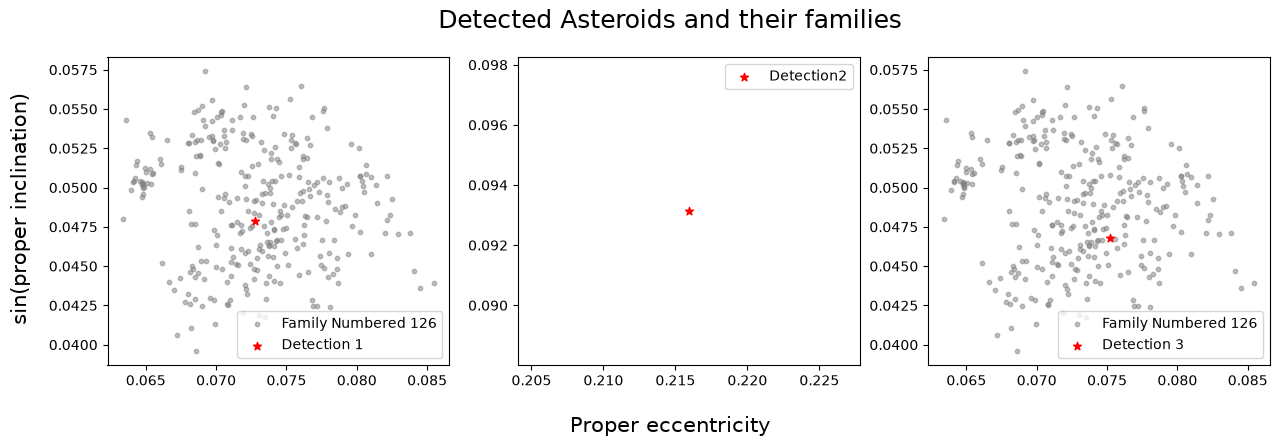

In [19]:
# Plot the detected asteroids with their family in the proper elements phase space
n = len(df_e)
fig, axes = plt.subplots(1, n, figsize=(int(n*5), 4))

for i in range(n):
	family_number = results_df.iloc[i]["matched_families"]
	if len(family_number) == 0:
		axes[i].scatter(merged_df.iloc[i]["pred_e"], merged_df.iloc[i]["pred_sini"], c = "red", marker='*', s = 35, alpha = 1, label = f"Detection{ i+1}")
		axes[i].legend()
	else:
		df_family = pd.read_csv(
			family_file_map[family_number[0]],
			header=None,
			names=column_names)
		fam_prope = df_family["prope"]
		fam_propsini = df_family["propsini"]
		axes[i].scatter(fam_prope, fam_propsini, c = "grey", s = 10, alpha = 0.5, label = f"Family Numbered {family_number[0]}")
		axes[i].scatter(merged_df.iloc[i]["pred_e"], merged_df.iloc[i]["pred_sini"], c = "red", marker='*', s = 35, alpha = 1, label = f"Detection { i+1}")
		axes[i].legend()

fig.suptitle("Detected Asteroids and their families",fontsize=18, y=1.0)
fig.supxlabel("Proper eccentricity", y = -0.07, size = 15)
fig.supylabel("sin(proper inclination)", x = 0.06, size = 15)
fig.savefig("./plots/pipeline_examples.pdf", bbox_inches='tight')
fig.show()

In [20]:
for r, ast in df_e.iterrows():
    matched_families = results_df['matched_families'][r]
    print(f"The candidate '{ast["Des'n"]}' matched the following families: {[family_file_map[n].stem for n in matched_families]}")

The candidate 'K09WK5U' matched the following families: ['inner_126_velleda_fam3']
The candidate 'K22SH4P' matched the following families: []
The candidate 'custom-velleda' matched the following families: ['inner_126_velleda_fam3']
